<a href="https://colab.research.google.com/github/jajapuramshivasai/Advanced-Experimental-Techniques-in-Quantum-Materials/blob/main/Hall_bar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:107: SyntaxWarning: invalid escape sequence '\O'
<>:114: SyntaxWarning: invalid escape sequence '\p'
<>:117: SyntaxWarning: invalid escape sequence '\O'
<>:124: SyntaxWarning: invalid escape sequence '\p'
<>:132: SyntaxWarning: invalid escape sequence '\O'
<>:107: SyntaxWarning: invalid escape sequence '\O'
<>:114: SyntaxWarning: invalid escape sequence '\p'
<>:117: SyntaxWarning: invalid escape sequence '\O'
<>:124: SyntaxWarning: invalid escape sequence '\p'
<>:132: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_4355/2279446317.py:107: SyntaxWarning: invalid escape sequence '\O'
  axs[0].set_ylabel('Raw Resistance ($\Omega$)')
/tmp/ipykernel_4355/2279446317.py:114: SyntaxWarning: invalid escape sequence '\p'
  color='darkgreen', alpha=0.3, label='$\pm1\sigma$ Error')
/tmp/ipykernel_4355/2279446317.py:117: SyntaxWarning: invalid escape sequence '\O'
  axs[1].set_ylabel('Magnetoresistance ($\Omega$)')
/tmp/ipykernel_4355/2279446317.py:124: SyntaxWarning: invalid escape s


           HALL MEASUREMENT RESULTS
Average Magnetoresistance : -3.858050e-02 Ohms
Net MR Error              :  5.387036e-07 Ohms
--------------------------------------------------
Extracted Hall Slope (R_H): -1.210884e-07 Ohms/Oe
Net Hall Slope Error      :  2.629448e-10 Ohms/Oe



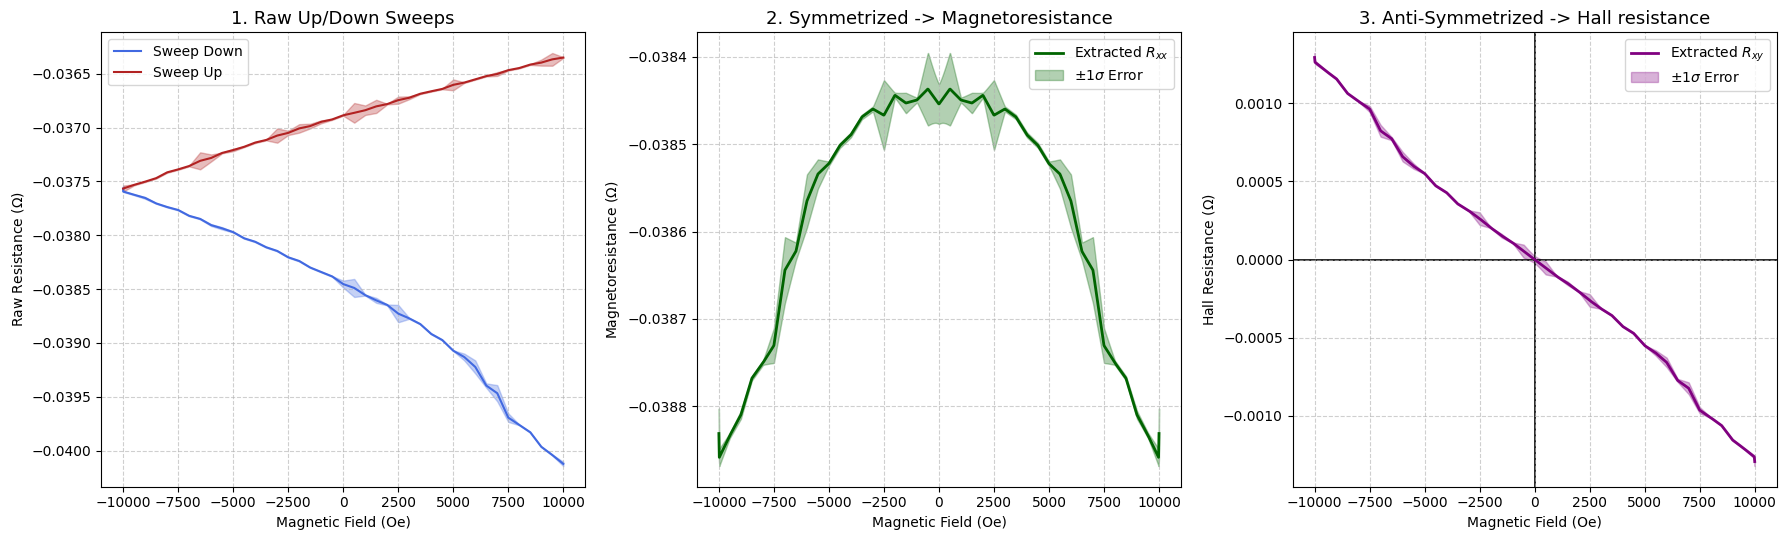

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import re

def full_hall_analysis(filename):
    # ==========================================
    # 1. Data Loading & Cleaning
    # ==========================================
    with open(filename, 'r') as f:
        lines = f.readlines()

    header_line = re.sub(r'\\s*', '', lines[0].strip())
    header = header_line.split('\t')

    data = []
    for line in lines[1:]:
        if line.strip() and not line.startswith('}'):
            data.append([float(x) for x in line.strip().split('\t')])

    df = pd.DataFrame(data, columns=header)

    # Absolute value for strictly positive standard deviations
    df['Error'] = np.abs(df['Resistance Std. Dev. Ch1 (Ohms)'])

    # ==========================================
    # 2. Split Sweeps & Setup Interpolation
    # ==========================================
    min_idx = df['Field (Oe)'].idxmin()

    # Split into down and up sweeps
    df_down = df.iloc[:min_idx+1].sort_values(by='Field (Oe)')
    df_up = df.iloc[min_idx:].sort_values(by='Field (Oe)')

    # We use ONE sweep (df_down) to calculate symmetries to avoid hysteresis overlap
    res_interp = interp1d(df_down['Field (Oe)'], df_down['Resistance Ch1 (Ohms)'],
                          kind='linear', fill_value="extrapolate")
    err_interp = interp1d(df_down['Field (Oe)'], df_down['Error'],
                          kind='linear', fill_value="extrapolate")

    # Create symmetric grid from -10,000 to +10,000 Oe
    max_b = df_down['Field (Oe)'].max()
    b_grid = np.linspace(-max_b, max_b, 1000)

    # ==========================================
    # 3. Mathematical Extraction
    # ==========================================
    r_pos = res_interp(b_grid)
    r_neg = res_interp(-b_grid)
    err_pos = err_interp(b_grid)
    err_neg = err_interp(-b_grid)

    # Symmetries
    r_mr = (r_pos + r_neg) / 2.0                 # Magnetoresistance (Symmetric)
    r_hall = (r_pos - r_neg) / 2.0               # Hall Resistance (Anti-symmetric)

    # Error Propagation (Quadrature addition)
    r_err_sym = np.sqrt(err_pos**2 + err_neg**2) / 2.0

    # ==========================================
    # 4. Averages and Metrics Calculation
    # ==========================================
    # 4a. Average Magnetoresistance & Net Error
    mean_mr = np.mean(r_mr)
    # The standard error of the mean = sqrt(sum(errors^2)) / N
    mean_mr_err = np.sqrt(np.sum(r_err_sym**2)) / len(r_err_sym)

    # 4b. Hall Properties
    # Since average of an odd function from -B to +B is exactly 0,
    # we calculate the Hall Slope (R_H) using polyfit with covariance
    coeffs, cov = np.polyfit(b_grid, r_hall, 1, cov=True)
    hall_slope = coeffs[0]
    hall_slope_err = np.sqrt(np.diag(cov))[0]

    # Output the metrics to the console
    print("\n" + "="*50)
    print("           HALL MEASUREMENT RESULTS")
    print("="*50)
    print(f"Average Magnetoresistance : {mean_mr:+.6e} Ohms")
    print(f"Net MR Error              :  {mean_mr_err:.6e} Ohms")
    print("-" * 50)
    print(f"Extracted Hall Slope (R_H): {hall_slope:+.6e} Ohms/Oe")
    print(f"Net Hall Slope Error      :  {hall_slope_err:.6e} Ohms/Oe")
    print("="*50 + "\n")

    # ==========================================
    # 5. Comprehensive Plotting
    # ==========================================
    fig, axs = plt.subplots(1, 3, figsize=(18, 5.5))

    # --- Plot 1: Up and Down Sweeps ---
    axs[0].plot(df_down['Field (Oe)'], df_down['Resistance Ch1 (Ohms)'], color='royalblue', label='Sweep Down')
    axs[0].fill_between(df_down['Field (Oe)'],
                        df_down['Resistance Ch1 (Ohms)'] - df_down['Error'],
                        df_down['Resistance Ch1 (Ohms)'] + df_down['Error'],
                        color='royalblue', alpha=0.3)

    axs[0].plot(df_up['Field (Oe)'], df_up['Resistance Ch1 (Ohms)'], color='firebrick', label='Sweep Up')
    axs[0].fill_between(df_up['Field (Oe)'],
                        df_up['Resistance Ch1 (Ohms)'] - df_up['Error'],
                        df_up['Resistance Ch1 (Ohms)'] + df_up['Error'],
                        color='firebrick', alpha=0.3)

    axs[0].set_title('1. Raw Up/Down Sweeps', fontsize=13)
    axs[0].set_xlabel('Magnetic Field (Oe)')
    axs[0].set_ylabel('Raw Resistance ($\Omega$)')
    axs[0].grid(True, linestyle='--', alpha=0.6)
    axs[0].legend(loc='best')

    # --- Plot 2: Symmetrized Magnetoresistance ---
    axs[1].plot(b_grid, r_mr, color='darkgreen', linewidth=2, label='Extracted $R_{xx}$')
    axs[1].fill_between(b_grid, r_mr - r_err_sym, r_mr + r_err_sym,
                        color='darkgreen', alpha=0.3, label='$\pm1\sigma$ Error')
    axs[1].set_title('2. Symmetrized -> Magnetoresistance', fontsize=13)
    axs[1].set_xlabel('Magnetic Field (Oe)')
    axs[1].set_ylabel('Magnetoresistance ($\Omega$)')
    axs[1].grid(True, linestyle='--', alpha=0.6)
    axs[1].legend(loc='best')

    # --- Plot 3: Anti-Symmetrized Hall Resistance ---
    axs[2].plot(b_grid, r_hall, color='purple', linewidth=2, label='Extracted $R_{xy}$')
    axs[2].fill_between(b_grid, r_hall - r_err_sym, r_hall + r_err_sym,
                        color='purple', alpha=0.3, label='$\pm1\sigma$ Error')

    # Draw Origin
    axs[2].axhline(0, color='black', linewidth=1.2, zorder=1)
    axs[2].axvline(0, color='black', linewidth=1.2, zorder=1)

    axs[2].set_title('3. Anti-Symmetrized -> Hall resistance', fontsize=13)
    axs[2].set_xlabel('Magnetic Field (Oe)')
    axs[2].set_ylabel('Hall Resistance ($\Omega$)')
    axs[2].grid(True, linestyle='--', alpha=0.6)
    axs[2].legend(loc='best')

    plt.tight_layout()
    plt.show()

# Run the final integrated analysis!
target_file = 'Al_bar_Hall_1T_300K_29April26.txt'
full_hall_analysis(target_file)

In [16]:
import pandas as pd
import re

filename = 'Al_bar_Hall_1T_300K_29April26.txt'

# 1. Data Loading & Cleaning
with open(filename, 'r') as f:
    lines = f.readlines()

# Extract and clean header
header_line = re.sub(r'\\s*', '', lines[0].strip()) # Use double backslash for regex in string
header = header_line.split('\t') # Split by tab

# Parse data lines
data = []
for line in lines[1:]:
    if line.strip() and not line.startswith('}'): # Skip empty lines and lines starting with '}'
        data.append([float(x) for x in line.strip().split('\t')]) # Convert to float and split by tab

# Create DataFrame
df = pd.DataFrame(data, columns=header)

# print(df)

In [17]:
pd.set_option('display.max_rows', None)
display(df)
pd.reset_option('display.max_rows')

,Field (Oe),Resistance Ch1 (Ohms),Resistance Std. Dev. Ch1 (Ohms),Phase Angle Ch1 (deg),AC Current Ch1 (mA),2nd Harmonic Ch1 (dB)
0,10000.566406,-0.040124,-0.000020,180.0412,1.0,-77.21645
1,9500.222656,-0.040042,-0.000004,180.0410,1.0,-78.02535
2,9000.138672,-0.039965,-0.000004,180.0411,1.0,-79.21428
3,8500.480469,-0.039831,-0.000004,180.0383,1.0,-89.57012
4,8000.528320,-0.039762,-0.000003,180.0395,1.0,-80.35796
5,7500.395996,-0.039695,-0.000040,180.0383,1.0,-82.60512
6,7000.558594,-0.039468,-0.000076,180.0384,1.0,-87.58522
7,6500.246582,-0.039397,-0.000020,180.0423,1.0,-77.69395
8,6000.522949,-0.039224,-0.000061,180.0387,1.0,-90.97642
9,5500.423340,-0.039132,-0.000032,180.0406,1.0,-80.33044
